Name: Adwaith Krishna M H 

Class: R3AI  Roll No: B25CTA12

Date: 11/9/2026

Q) An environmental research team wants to automatically group different flower species based on their physical characteristics. the dataset iris.csv contains the following attributes: SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, and species.

tasks:
1. load the iris dataset and display the first few records.
2. drop the species column and consider only numerical features for clustering
3. apply k means clustering with n_clusters = 3 (since the dataset has three species)
4. add the cluster labels to the dataset as a new column named Cluster
5. visualize the clusters using a scatter plot (eg. PetalLengthCm vs PetalWidthCm) with different colours for ech cluster
6. compare the obtained cluster labels with the actual species column to evaluate clustering performance

1. Import libraries and load the dataset

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(r"C:\Users\adwai\Downloads\Iriss.csv")

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


2. Select numerical features

In [18]:
X = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]]

print(X.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2


3. Apply K-Means clustering

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X)

print(df["Cluster"])

0      1
1      1
2      1
3      1
4      1
      ..
145    2
146    0
147    2
148    2
149    0
Name: Cluster, Length: 150, dtype: int32


4. Add cluster labels

In [20]:
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


5. Visualize clusters

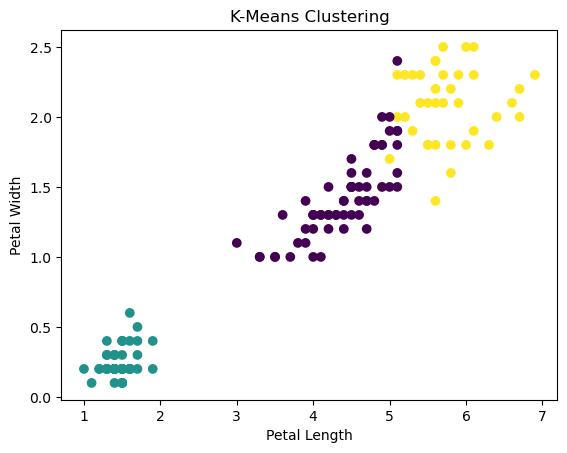

In [21]:
plt.scatter(
    df["PetalLengthCm"],
    df["PetalWidthCm"],
    c=df["Cluster"]
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering")

plt.show()

6. Compare clusters with actual species

In [22]:
print(df[["Species", "Cluster"]])

print(pd.crosstab(df["Species"], df["Cluster"]))

            Species  Cluster
0       Iris-setosa        1
1       Iris-setosa        1
2       Iris-setosa        1
3       Iris-setosa        1
4       Iris-setosa        1
..              ...      ...
145  Iris-virginica        2
146  Iris-virginica        0
147  Iris-virginica        2
148  Iris-virginica        2
149  Iris-virginica        0

[150 rows x 2 columns]
Cluster           0   1   2
Species                    
Iris-setosa       0  50   0
Iris-versicolor  48   0   2
Iris-virginica   14   0  36


7. Evaluate clustering performance

In [23]:
from sklearn.metrics import accuracy_score

mapping = {}

for cluster in df["Cluster"].unique():
    mapping[cluster] = df[df["Cluster"] == cluster]["Species"].mode()[0]

df["PredictedSpecies"] = df["Cluster"].map(mapping)

accuracy = accuracy_score(
    df["Species"],
    df["PredictedSpecies"]
)

print("Accuracy:", accuracy * 100, "%")

Accuracy: 89.33333333333333 %
